In [2]:
import csv

one_epoch_results = {}

with open("./results/one_epoch.csv", "r", newline="") as f:
    reader = csv.DictReader(f)
    for row in reader:
        one_epoch_results[row["experiment_name"]] = float(row["val_loss"])

print(len(one_epoch_results))

TOKENS_MAP = {
    "100m": 0.1,
    "130m": 0.13,
    "200m": 0.2,
    "400m": 0.4,
    "800m": 0.8,
    "0b13": 0.13,
    "0b26": 0.26,
    "0b52": 0.52,
    "1b04": 1.04,
    "1b3": 1.3,
    "2b6": 2.6,
    "5b2": 5.2,
    "10b4": 10.4,
    "20b8": 20.8,
    "174b": 174,
    "178b": 178
}

PARAMS_MAP = {
    "44m": 4.4E+07,
    "83m": 8.27E+07,
    "15m": 2.7E+07,
    "30m": 4.5E+07,
    "60m": 8.0E+07,
    "120m": 1.45E+08,
    "240m": 2.68E+08,
    "480m": 5.21E+08,
    "960m": 1.17E+09,
    "1b92": 1.99E+09,
}


DENS_MAP = {
    "s0625": 0.0625,
    "s125": 0.125,
    "s25": 0.25,
    "s5": 0.5,
    "s": 1.0,}

232


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from tqdm import tqdm

torch.set_default_dtype(torch.float64)
device = "cuda" if torch.cuda.is_available() else "cpu"

model_params = []
tokens = []
unique_tokens = []
losses = []
names = []
densities = []


def get_params(name):
    idx = 2
    while name[:idx] not in PARAMS_MAP:
        idx += 1
    params = PARAMS_MAP[name[:idx]]
    return params, idx


def get_unique_tokens(name):
    max_token_len = max(len(k) for k in TOKENS_MAP)

    for l in range(max_token_len, 2, -1):
        ut_candidate = name[-l:]
        if ut_candidate in TOKENS_MAP:
            return TOKENS_MAP[ut_candidate] * 1e9, len(name) - l

    ut_fallback = name[-4:]
    ut_val = float(ut_fallback.replace("b", ".").strip("."))
    return ut_val * 1e9, len(name) - 4


def get_tokens(tokens):
    if tokens in TOKENS_MAP:
        tokens = TOKENS_MAP[tokens]
    else:
        tokens = float(tokens.replace("b", ".").strip("."))

    return tokens * 1e9


def get_density(name):
    for suffix in DENS_MAP:
        if name.endswith(suffix):
            return DENS_MAP[suffix], name[:-len(suffix)]
    return 1.0, name


for name, loss_ in one_epoch_results.items():
    if loss_ != 0 and not name.endswith("dedup"):
        density, trimmed_name = get_density(name)
        p, tok_start_idx = get_params(trimmed_name)
        ut, tok_end_idx = get_unique_tokens(trimmed_name)
        t = get_tokens(trimmed_name[tok_start_idx:tok_end_idx])

        model_params.append(p)
        unique_tokens.append(ut)
        tokens.append(t)
        losses.append(loss_)
        densities.append(density)
        names.append(name)


inp_all = torch.tensor(
    [[p, t, l, s] for p, t, l, s in zip(model_params, tokens, losses, densities)],
    dtype=torch.get_default_dtype(),
    device=device,
)


# 3) First stage: only density == 1 result
density_one = torch.tensor(1.0, dtype=inp_all.dtype, device=device)
mask_density1 = torch.isclose(inp_all[:, 3], density_one)
inp_stage1 = inp_all[mask_density1]

print("All samples:", len(inp_all))
print("Stage 1 density=1 samples:", len(inp_stage1))


# 4) First stage: alpha = beta
def loss_stage1(inp, theta):
    """
    theta = [a, b, e, alpha]
    beta = alpha
    """
    a, b, e, alpha = theta
    beta = alpha

    pre_lse = torch.stack([
        a - alpha * torch.log(inp[:, 0]),
        b - beta  * torch.log(inp[:, 1]),
        e.expand(inp.shape[0]),
    ])

    pred_log_loss = torch.logsumexp(pre_lse, dim=0)
    target_log_loss = torch.log(torch.clamp(inp[:, 2], min=1e-8))

    return torch.nn.functional.huber_loss(
        pred_log_loss,
        target_log_loss,
        delta=1e-3,
        reduction="sum",
    )


def minimize_stage1(inp, init_params, steps=50):
    theta = torch.nn.Parameter(
        torch.tensor(
            init_params,
            dtype=torch.get_default_dtype(),
            device=device,
        )
    )

    optimizer = torch.optim.LBFGS(
        [theta],
        lr=1e-1,
        history_size=10,
        max_iter=20,
        line_search_fn="strong_wolfe",
    )

    for _ in range(steps):
        def closure():
            optimizer.zero_grad()
            L = loss_stage1(inp, theta)
            L.backward()
            return L

        optimizer.step(closure)

    final_loss = loss_stage1(inp, theta).item()
    final_params = theta.detach().cpu().numpy()

    return final_loss, final_params


best_stage1 = (float("inf"), None)

grid_a = np.linspace(0, 10, 5)
grid_b = np.linspace(0, 10, 5)
grid_e = np.linspace(-1, 1, 4)
grid_alpha = np.linspace(0, 1, 4)

for a in tqdm(grid_a):
    for b in grid_b:
        for e in grid_e:
            for alpha in grid_alpha:
                init_params = [a, b, e, alpha]

                cur_loss, cur_params = minimize_stage1(
                    inp_stage1,
                    init_params,
                    steps=50,
                )

                if cur_loss < best_stage1[0]:
                    best_stage1 = (cur_loss, cur_params)
                    print("New Stage 1 best:", best_stage1)

stage1_loss, stage1_params = best_stage1

a0, b0, e0, alpha0 = stage1_params
beta0 = alpha0

print("\nStage 1 final result")
print("Loss:", stage1_loss)
print("a:", a0)
print("b:", b0)
print("e:", e0)
print("alpha:", alpha0)
print("beta:", beta0)
print("Params [a, b, e, alpha]:", stage1_params)

All samples: 232
Stage 1 density=1 samples: 47


  0%|          | 0/5 [00:00<?, ?it/s]

New Stage 1 best: (0.0005171996697022204, array([ 2.149307  ,  2.37397837, -0.22556378,  0.10361174]))
New Stage 1 best: (0.0002353350675160156, array([6.65276367, 7.80268843, 0.90497966, 0.41259321]))
New Stage 1 best: (0.00023533491799112368, array([6.65163203, 7.80103646, 0.90494103, 0.41251469]))
New Stage 1 best: (0.00023533470156974768, array([6.65286723, 7.80259918, 0.90498844, 0.41259309]))


 20%|██        | 1/5 [01:50<07:22, 110.68s/it]

New Stage 1 best: (0.00023533465889400944, array([6.65297827, 7.80278907, 0.90499715, 0.41260272]))


 60%|██████    | 3/5 [03:38<02:06, 63.39s/it] 

New Stage 1 best: (0.0002353346581255041, array([6.6528737 , 7.80266782, 0.9049929 , 0.41259631]))


100%|██████████| 5/5 [05:54<00:00, 70.85s/it]


Stage 1 final result
Loss: 0.0002353346581255041
a: 6.652873704097015
b: 7.802667823192029
e: 0.904992903558749
alpha: 0.41259630758125987
beta: 0.41259630758125987
Params [a, b, e, alpha]: [6.6528737  7.80266782 0.9049929  0.41259631]


In [5]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import r2_score

a0, b0, e0, alpha0= stage1_params
beta0 = alpha0
inp_stage2 = inp_all

print("Stage 2 samples:", len(inp_stage2))

def loss_stage2_joint(inp, theta):
    """
    theta = [a, b, e, alpha, epsion, mu, c]
    beta = alpha

    inp[:, 0] = raw params
    inp[:, 1] = tokens
    inp[:, 2] = loss
    inp[:, 3] = density
    """
    a, b, e, alpha, epsion, mu, c = theta
    beta = alpha

    N_raw = inp[:, 0]
    D = inp[:, 1]
    y = inp[:, 2]
    s = torch.clamp(inp[:, 3], min=1e-8, max=1 - 1e-8)

    N_eff = torch.clamp(N_raw * s, min=1e-8)

    density_factor = torch.clamp(
        s ** epsion + c * (1 - s) ** mu,
        min=1e-12,
    )

    pre_lse = torch.stack([
        a - alpha * torch.log(N_eff) + torch.log(density_factor),
        b - beta  * torch.log(D),
        e.expand(inp.shape[0]),
    ])

    pred_log_loss = torch.logsumexp(pre_lse, dim=0)
    target_log_loss = torch.log(torch.clamp(y, min=1e-8))

    return torch.nn.functional.huber_loss(
        pred_log_loss,
        target_log_loss,
        delta=1e-3,
        reduction="sum",
    )


def minimize_stage2_joint(inp, init_params, steps=50):
    theta = torch.nn.Parameter(
        torch.tensor(
            init_params,
            dtype=torch.get_default_dtype(),
            device=device,
        )
    )

    optimizer = torch.optim.LBFGS(
        [theta],
        lr=1e-1,
        history_size=10,
        max_iter=20,
        line_search_fn="strong_wolfe",
    )

    for _ in range(steps):
        def closure():
            optimizer.zero_grad()
            L = loss_stage2_joint(inp, theta)
            L.backward()
            return L

        optimizer.step(closure)

    final_loss = loss_stage2_joint(inp, theta).item()
    final_params = theta.detach().cpu().numpy()

    return final_loss, final_params


# ============================================================
# a,b,e,alpha from the results of stage 1
# ============================================================

best_stage2 = (float("inf"), None)

grid_epsion = np.linspace(-2, 2, 5)
grid_mu = np.linspace(-2, 2, 5)
grid_c = np.linspace(-2, 2, 5)

for epsion in tqdm(grid_epsion):
    for mu in grid_mu:
        for c in grid_c:
            init_params = [
                a0,
                b0,
                e0,
                alpha0,
                epsion,
                mu,
                c,
            ]

            cur_loss, cur_params = minimize_stage2_joint(
                inp_stage2,
                init_params,
                steps=50,
            )

            if cur_loss < best_stage2[0]:
                best_stage2 = (cur_loss, cur_params)
                print("New Stage 2 best:", best_stage2)

stage2_loss, stage2_params = best_stage2

a2, b2, e2, alpha2, epsion2, mu2, c2 = stage2_params
beta2 = alpha2

print("\nStage 2 joint final result")
print("Loss:", stage2_loss)
print("a:", a2)
print("b:", b2)
print("e:", e2)
print("alpha:", alpha2)
print("beta:", beta2)
print("epsion:", epsion2)
print("mu:", mu2)
print("c:", c2)
print("Params [a, b, e, alpha, epsion, mu, c]:", stage2_params)


# ============================================================
# R2 
# ============================================================

def scaling_law_stage2_joint(N_raw, D, s, params):
    """
    params = [a, b, e, alpha, epsion, mu, c]
    beta = alpha
    """
    a, b, e, alpha, epsion, mu, c = params
    beta = alpha

    A = np.exp(a)
    B = np.exp(b)
    E = np.exp(e)

    s = np.clip(s, 1e-8, 1 - 1e-8)
    N_eff = np.clip(N_raw * s, 1e-8, None)

    density_factor = s ** epsion + c * (1 - s) ** mu
    L = (
        E
        + A * density_factor / (N_eff ** alpha)
        + B / (D ** beta)
    )
    return L, density_factor, N_eff, D


raw_model_params_np = np.array(model_params)
tokens_np = np.array(tokens)
losses_np = np.array(losses)
densities_np = np.array(densities)

y_true_all = losses_np
y_pred_all, density_factor, N_eff, D = scaling_law_stage2_joint(
    raw_model_params_np,
    tokens_np,
    densities_np,
    stage2_params,
)

r2_all = r2_score(y_true_all, y_pred_all)

print("\nStage 2 joint R2 on all data:", r2_all)
 
mask_density_not1 = ~np.isclose(densities_np, 1.0)

if mask_density_not1.sum() > 1:
    r2_density_not1 = r2_score(
        losses_np[mask_density_not1],
        y_pred_all[mask_density_not1],
    )
    print("Stage 2 joint R2 on density != 1 data:", r2_density_not1)

mask_density1 = np.isclose(densities_np, 1.0)

if mask_density1.sum() > 1:
    r2_density1 = r2_score(
        losses_np[mask_density1],
        y_pred_all[mask_density1],
    )
    print("Stage 2 joint R2 on density == 1 data:", r2_density1)


final_params = {
    "a": a2,
    "b": b2,
    "e": e2,
    "alpha": alpha2,
    "beta": beta2,
    "epsion": epsion2,
    "mu": mu2,
    "c": c2,
}

print("\nFinal params:")
print(final_params)

Stage 2 samples: 232


  0%|          | 0/5 [00:00<?, ?it/s]

New Stage 2 best: (0.007624459395978974, array([ 6.78961707e+00,  7.86961811e+00,  1.03106685e+00,  4.11610675e-01,
        4.50268018e-03, -1.91991459e+00, -1.83718250e+00]))
New Stage 2 best: (0.0076239191633014035, array([ 6.77916841,  7.84524118,  1.0305903 ,  0.41028335,  0.0349474 ,
       -1.96590664, -0.86248706]))
New Stage 2 best: (0.007623082774379412, array([ 6.64854614e+00,  7.80665131e+00,  1.02975865e+00,  4.08169507e-01,
       -1.99223746e+00, -2.00000000e+00, -9.60791693e+07]))
New Stage 2 best: (0.0029237664995721167, array([ 6.57847799e+00,  8.40346364e+00,  9.84913944e-01,  4.48418463e-01,
        5.14136919e-02, -6.73570063e-01,  1.13126557e-06]))
New Stage 2 best: (0.0014151669119225876, array([5.19785975, 6.15251858, 0.85930925, 0.32930751, 2.749716  ,
       0.14063262, 0.84244643]))
New Stage 2 best: (0.0013811230735143879, array([4.53885954, 6.10741333, 0.85554518, 0.32692379, 2.4763852 ,
       0.02426615, 1.5583984 ]))
New Stage 2 best: (0.00136739975115850

 20%|██        | 1/5 [01:59<07:59, 119.88s/it]

New Stage 2 best: (0.0013673991435626187, array([ 5.24073718,  6.10303089,  0.85355013,  0.32682177, -0.00968044,
        0.84661793, -0.27288932]))


100%|██████████| 5/5 [07:36<00:00, 91.35s/it] 


Stage 2 joint final result
Loss: 0.0013673991435626187
a: 5.240737178917673
b: 6.103030891809012
e: 0.8535501324918354
alpha: 0.3268217718148829
beta: 0.3268217718148829
epsion: -0.009680437509279435
mu: 0.8466179337054532
c: -0.2728893199074849
Params [a, b, e, alpha, epsion, mu, c]: [ 5.24073718  6.10303089  0.85355013  0.32682177 -0.00968044  0.84661793
 -0.27288932]

Stage 2 joint R2 on all data: 0.9839975264809121
Stage 2 joint R2 on density != 1 data: 0.9847555407383451
Stage 2 joint R2 on density == 1 data: 0.9805973392959888

Final params:
{'a': 5.240737178917673, 'b': 6.103030891809012, 'e': 0.8535501324918354, 'alpha': 0.3268217718148829, 'beta': 0.3268217718148829, 'epsion': -0.009680437509279435, 'mu': 0.8466179337054532, 'c': -0.2728893199074849}


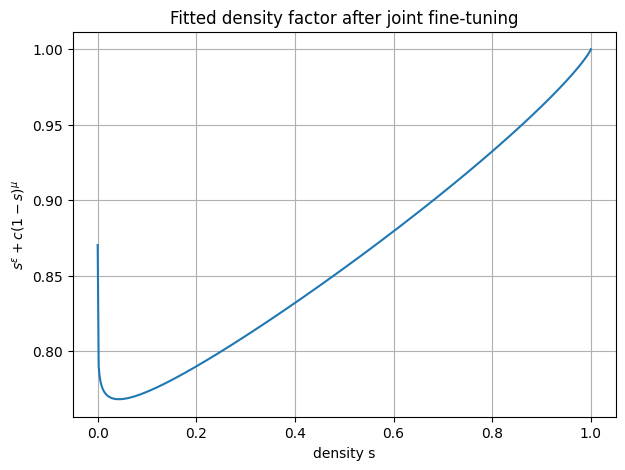

In [6]:
s_grid = np.linspace(1e-6, 1 - 1e-6, 500)

density_factor = (
    s_grid ** epsion2
    + c2 * (1 - s_grid) ** mu2
)

plt.figure(figsize=(7, 5))
plt.plot(s_grid, density_factor)
plt.xlabel("density s")
plt.ylabel(r"$s^{\epsilon} + c(1-s)^{\mu}$")
plt.title("Fitted density factor after joint fine-tuning")
plt.grid(True)
plt.show()

In [7]:
csv_path = "./results/dense_multi_epoch.csv"
Dense_MultiEpoch_Results = {}
with open(csv_path, "r", newline="") as f:
    reader = csv.DictReader(f)
    Dense_MultiEpoch_Results = {
        row["experiment_name"]: float(row["val_loss"])
        for row in reader
    }
print(len(Dense_MultiEpoch_Results))

TOKENS_MAP = {
    "100m": 0.1,
    "130m": 0.13,
    "200m": 0.2,
    "400m": 0.4,
    "800m": 0.8,
    "0b13": 0.13,
    "0b26": 0.26,
    "0b52": 0.52,
    "1b04": 1.04,
    "1b3": 1.3,
    "2b6": 2.6,
    "5b2": 5.2,
    "10b4": 10.4,
    "20b8": 20.8,
    "174b": 174,
    "178b": 178
}

PARAMS_MAP = {
    "44m": 4.4E+07,
    "83m": 8.27E+07,
    "15m": 2.7E+07,
    "30m": 4.5E+07,
    "60m": 8.0E+07,
    "120m": 1.45E+08,
    "240m": 2.68E+08,
    "480m": 5.21E+08,
    "960m": 1.17E+09,
    "1b92": 1.99E+09,
}

DENS_MAP = {
    "s0625": 0.0625,
    "s125": 0.125,
    "s25": 0.25,
    "s5": 0.5,
    "s": 1.0,
}


63


In [9]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import r2_score

raw_model_params = []
effective_model_params = []
tokens = []
unique_tokens = []
losses = []
names = []
densities = []

torch.set_default_dtype(torch.float64)
device = "cuda" if torch.cuda.is_available() else "cpu"


def get_params(name):
    idx = 2
    while name[:idx] not in PARAMS_MAP:
        idx += 1
    params = PARAMS_MAP[name[:idx]]
    return params, idx


def get_unique_tokens(name):
    max_token_len = max(len(k) for k in TOKENS_MAP)

    for l in range(max_token_len, 2, -1):
        ut_candidate = name[-l:]
        if ut_candidate in TOKENS_MAP:
            return TOKENS_MAP[ut_candidate] * 1e9, len(name) - l

    ut_fallback = name[-4:]
    ut_val = float(ut_fallback.replace("b", ".").strip("."))
    return ut_val * 1e9, len(name) - 4


def get_tokens(tokens_str):
    if tokens_str in TOKENS_MAP:
        tokens_val = TOKENS_MAP[tokens_str]
    else:
        tokens_val = float(tokens_str.replace("b", ".").strip("."))

    return tokens_val * 1e9


def get_density(name):
    for suffix in DENS_MAP:
        if name.endswith(suffix):
            return DENS_MAP[suffix], name[:-len(suffix)]
    return 1.0, name


for name, loss_ in Dense_MultiEpoch_Results.items():
    if loss_ != 0 and not name.endswith("dedup"):
        density, trimmed_name = get_density(name)

        p_raw, tok_start_idx = get_params(trimmed_name)
        ut, tok_end_idx = get_unique_tokens(trimmed_name)
        t = get_tokens(trimmed_name[tok_start_idx:tok_end_idx])

        raw_model_params.append(p_raw)
        effective_model_params.append(p_raw * density)
        unique_tokens.append(ut)
        tokens.append(t)
        losses.append(loss_)
        densities.append(density)
        names.append(name)
        
inp_all = torch.tensor(
    [
        [p_raw, p_eff, t, ut, l, s]
        for p_raw, p_eff, t, ut, l, s in zip(
            raw_model_params,
            effective_model_params,
            tokens,
            unique_tokens,
            losses,
            densities,
        )
    ],
    dtype=torch.get_default_dtype(),
    device=device,
)

In [10]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import r2_score

a2, b2, e2, alpha2, epsion2, mu2, c2 =  stage2_params

beta2 = alpha2

A2 = np.exp(a2)
B2 = np.exp(b2)
E2 = np.exp(e2)


def optimal_N_stage3(C, s):
    a_exp = beta2 / (alpha2 + beta2)
    density_factor = s ** epsion2 + c2 * (1 - s) ** mu2
    A_t = density_factor * A2
    G = ((alpha2 * A_t) / (beta2 * B2)) ** (1 / (alpha2 + beta2))
    return G * (C / 6) ** a_exp


def D_to_C_stage3(D, s):
    b_exp = alpha2 / (alpha2 + beta2)
    density_factor = s ** epsion2 + c2 * (1 - s) ** mu2
    A_t = density_factor * A2
    G = ((alpha2 * A_t) / (beta2 * B2)) ** (1 / (alpha2 + beta2))
    return ((G * D) ** (1 / b_exp)) * 6


# ============================================================
#   inp_all[:, 0] = raw params
#   inp_all[:, 1] = effective params = raw params * density
#   inp_all[:, 2] = tokens
#   inp_all[:, 3] = unique tokens
#   inp_all[:, 4] = loss
#   inp_all[:, 5] = density
#
#   0: N_star
#   1: U
#   2: rn
#   3: rd
#   4: loss
#   5: density
#   6: N_eff_original = raw params * density
#   7: D_original = tokens
# ============================================================

inp_np = inp_all.detach().cpu().numpy()

inp_stage3_list = []

for row in inp_np:
    p_raw = row[0]
    p_eff = row[1]
    t = row[2]
    ut = row[3]
    l = row[4]
    s = row[5]

    n_opt_from_ut = optimal_N_stage3(
        D_to_C_stage3(ut, s),
        s,
    )

    N_star = min(n_opt_from_ut, p_eff)

    rn = max(p_eff / N_star - 1, 0)
    rd = max(t / ut - 1, 0)

    inp_stage3_list.append([
        N_star,
        ut,
        rn,
        rd,
        l,
        s,
        p_eff,
        t,
    ])

inp_stage3 = torch.tensor(
    inp_stage3_list,
    dtype=torch.get_default_dtype(),
    device=device,
)

print("Stage 3 samples:", len(inp_stage3))


def loss_stage3(inp, theta_star):
    """
    theta_star = [n_star, ep_star]

    inp columns:
        0: N_star
        1: U
        2: rn
        3: rd
        4: loss
        5: density
        6: original effective params
        7: original tokens
    """
    n_star, ep_star = theta_star

    N_star = inp[:, 0]
    U = inp[:, 1]
    rn = inp[:, 2]
    rd = inp[:, 3]
    y = inp[:, 4]
    s = torch.clamp(inp[:, 5], min=1e-8, max=1 - 1e-8)

    N_eff = N_star + N_star * n_star * (1 - torch.exp(-rn / n_star))
    D_eff = U + U * ep_star * (1 - torch.exp(-rd / ep_star))

    N_eff = torch.clamp(N_eff, min=1e-8)
    D_eff = torch.clamp(D_eff, min=1e-8)

    density_factor = torch.clamp(
        s ** epsion2 + c2 * (1 - s) ** mu2,
        min=1e-12,
    )

    e_term = torch.zeros_like(N_eff) + e2

    pre_lse = torch.stack([
        a2 - alpha2 * torch.log(N_eff) + torch.log(density_factor),
        b2 - beta2  * torch.log(D_eff),
        e_term,
    ])

    pred_log_loss = torch.logsumexp(pre_lse, dim=0)
    target_log_loss = torch.log(torch.clamp(y, min=1e-8))

    return torch.nn.functional.huber_loss(
        pred_log_loss,
        target_log_loss,
        delta=1e-3,
        reduction="sum",
    )


def minimize_stage3(inp, init_params, steps=50):
    theta_star = torch.nn.Parameter(
        torch.tensor(
            init_params,
            dtype=torch.get_default_dtype(),
            device=device,
        )
    )

    optimizer = torch.optim.LBFGS(
        [theta_star],
        lr=1e-1,
        history_size=10,
        max_iter=20,
        line_search_fn="strong_wolfe",
    )

    for _ in range(steps):
        def closure():
            optimizer.zero_grad()
            L = loss_stage3(inp, theta_star)
            L.backward()
            return L

        optimizer.step(closure)

    final_loss = loss_stage3(inp, theta_star).item()
    final_params = theta_star.detach().cpu().numpy()

    return final_loss, final_params


best_stage3 = (float("inf"), None)

grid_n_star = np.linspace(1, 20, 10)
grid_ep_star = np.linspace(1, 20, 10)

for n_star in tqdm(grid_n_star):
    for ep_star in grid_ep_star:
        init_params = [n_star, ep_star]

        cur_loss, cur_params = minimize_stage3(
            inp_stage3,
            init_params,
            steps=50,
        )

        if cur_loss < best_stage3[0]:
            best_stage3 = (cur_loss, cur_params)
            print("New Stage 3 best:", best_stage3)


stage3_loss, stage3_params = best_stage3
n_star3, ep_star3 = stage3_params

print("\nStage 3 final result")
print("Loss:", stage3_loss)
print("n_star:", n_star3)
print("ep_star:", ep_star3)
print("Params [n_star, ep_star]:", stage3_params)

Stage 3 samples: 63


  0%|          | 0/10 [00:00<?, ?it/s]

New Stage 3 best: (0.00024264972612588913, array([11.09091761,  4.40468837]))
New Stage 3 best: (0.0002426497143774057, array([11.08583357,  4.40482403]))


 20%|██        | 2/10 [00:24<01:34, 11.87s/it]

New Stage 3 best: (0.0002426497130467031, array([11.08685047,  4.40471462]))


...

New Stage 3 best: (0.00024264971302954944, array([11.08676451,  4.40491206]))


 90%|█████████ | 9/10 [01:16<00:08,  8.24s/it]

New Stage 3 best: (0.00024264971285092255, array([11.08763712,  4.40474882]))


100%|██████████| 10/10 [01:25<00:00,  8.59s/it]


Stage 3 final result
Loss: 0.00024264971285092255
n_star: 11.087637121468322
ep_star: 4.404748822323469
Params [n_star, ep_star]: [11.08763712  4.40474882]


In [12]:
csv_path = "./results/sparse_multi_epoch.csv"
Sparse_MultiEpoch_Results = {}
with open(csv_path, "r", newline="") as f:
    reader = csv.DictReader(f)
    Sparse_MultiEpoch_Results = {
        row["experiment_name"]: float(row["val_loss"])
        for row in reader
    }
print(len(Sparse_MultiEpoch_Results))

205


In [13]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import r2_score

raw_model_params = []
effective_model_params = []
tokens = []
unique_tokens = []
losses = []
names = []
densities = []

torch.set_default_dtype(torch.float64)
device = "cuda" if torch.cuda.is_available() else "cpu"


def get_params(name):
    idx = 2
    while name[:idx] not in PARAMS_MAP:
        idx += 1
    params = PARAMS_MAP[name[:idx]]
    return params, idx


def get_unique_tokens(name):
    max_token_len = max(len(k) for k in TOKENS_MAP)

    for l in range(max_token_len, 2, -1):
        ut_candidate = name[-l:]
        if ut_candidate in TOKENS_MAP:
            return TOKENS_MAP[ut_candidate] * 1e9, len(name) - l

    ut_fallback = name[-4:]
    ut_val = float(ut_fallback.replace("b", ".").strip("."))
    return ut_val * 1e9, len(name) - 4


def get_tokens(tokens_str):
    if tokens_str in TOKENS_MAP:
        tokens_val = TOKENS_MAP[tokens_str]
    else:
        tokens_val = float(tokens_str.replace("b", ".").strip("."))

    return tokens_val * 1e9


def get_density(name):
    for suffix in DENS_MAP:
        if name.endswith(suffix):
            return DENS_MAP[suffix], name[:-len(suffix)]
    return 1.0, name


for name, loss_ in Sparse_MultiEpoch_Results.items():
    if loss_ != 0 and not name.endswith("dedup"):
        density, trimmed_name = get_density(name)

        p_raw, tok_start_idx = get_params(trimmed_name)
        ut, tok_end_idx = get_unique_tokens(trimmed_name)
        t = get_tokens(trimmed_name[tok_start_idx:tok_end_idx])

        raw_model_params.append(p_raw)
        effective_model_params.append(p_raw * density)
        unique_tokens.append(ut)
        tokens.append(t)
        losses.append(loss_)
        densities.append(density)
        names.append(name)
        
inp_all = torch.tensor(
    [
        [p_raw, p_eff, t, ut, l, s]
        for p_raw, p_eff, t, ut, l, s in zip(
            raw_model_params,
            effective_model_params,
            tokens,
            unique_tokens,
            losses,
            densities,
        )
    ],
    dtype=torch.get_default_dtype(),
    device=device,
)

In [14]:
import numpy as np
import torch
from tqdm import tqdm
from sklearn.metrics import r2_score


a4, b4, e4, alpha4,  epsion4, mu4, c4 = stage2_params
beta4 = alpha4
gamma1, gamma2 = stage3_params


A4 = np.exp(a4)
B4 = np.exp(b4)
E4 = np.exp(e4)

print("gamma1 =", gamma1)
print("gamma2 =", gamma2)


def optimal_N_stage4(C, s):
    a_exp = beta4 / (alpha4 + beta4)

    density_factor = s ** epsion4 + c4 * (1 - s) ** mu4
    A_t = density_factor * A4

    G = ((alpha4 * A_t) / (beta4 * B4)) ** (1 / (alpha4 + beta4))

    return G * (C / 6) ** a_exp


def D_to_C_stage4(D, s):
    b_exp = alpha4 / (alpha4 + beta4)

    density_factor = s ** epsion4 + c4 * (1 - s) ** mu4
    A_t = density_factor * A4

    G = ((alpha4 * A_t) / (beta4 * B4)) ** (1 / (alpha4 + beta4))

    return ((G * D) ** (1 / b_exp)) * 6


# ============================================================
# inp_stage4 columns:
#   0: N_star
#   1: U = unique tokens
#   2: rn
#   3: rd
#   4: loss
#   5: density
#   6: N_eff_original
#   7: D_original
# ============================================================

inp_np = inp_all.detach().cpu().numpy()

inp_stage4_list = []

for row in inp_np:
    p_raw = row[0]
    p_eff = row[1]
    t = row[2]
    ut = row[3]
    l = row[4]
    s = row[5]

    n_opt_from_ut = optimal_N_stage4(
        D_to_C_stage4(ut, s),
        s,
    )

    N_star = min(n_opt_from_ut, p_eff)

    rn = max(p_eff / N_star - 1, 0)
    rd = max(t / ut - 1, 0)

    inp_stage4_list.append([
        N_star,
        ut,
        rn,
        rd,
        l,
        s,
        p_eff,
        t,
    ])

inp_stage4 = torch.tensor(
    inp_stage4_list,
    dtype=torch.get_default_dtype(),
    device=device,
)

print("Stage 4 samples:", len(inp_stage4))


def loss_stage4(inp, theta):
    """
    theta = [c11, c12, c21, c22]
    """
    c11, c12, c21, c22 = theta

    N_star = inp[:, 0]
    U = inp[:, 1]
    rn = inp[:, 2]
    rd = inp[:, 3]
    y = inp[:, 4]
    s = torch.clamp(inp[:, 5], min=1e-8, max=1 - 1e-8)

    one_minus_s = 1 - s

    n_star = gamma1 * (1
        + one_minus_s * c11
        - c21 * one_minus_s ** 2
    )

    ep_star = gamma2 * (
        1
        + one_minus_s * c12
        - c22 * one_minus_s ** 2
    )
    

    n_star = torch.clamp(n_star, min=1e-8)
    ep_star = torch.clamp(ep_star, min=1e-8)

    N_eff = N_star + N_star * n_star * (
        1 - torch.exp(-rn / n_star)
    )

    D_eff = U + U * ep_star * (
        1 - torch.exp(-rd / ep_star)
    )

    N_eff = torch.clamp(N_eff, min=1e-8)
    D_eff = torch.clamp(D_eff, min=1e-8)

    density_factor = torch.clamp(
        s ** epsion4 + c4 * (1 - s) ** mu4,
        min=1e-12,
    )

    e_term = torch.zeros_like(N_eff) + e4

    pre_lse = torch.stack([
        a4 - alpha4 * torch.log(N_eff) + torch.log(density_factor),
        b4 - beta4  * torch.log(D_eff),
        e_term,
    ])

    pred_log_loss = torch.logsumexp(pre_lse, dim=0)
    target_log_loss = torch.log(torch.clamp(y, min=1e-8))

    return torch.nn.functional.huber_loss(
        pred_log_loss,
        target_log_loss,
        delta=1e-3,
        reduction="sum",
    )


def minimize_stage4(inp, init_params, steps=50):
    theta = torch.nn.Parameter(
        torch.tensor(
            init_params,
            dtype=torch.get_default_dtype(),
            device=device,
        )
    )

    optimizer = torch.optim.LBFGS(
        [theta],
        lr=1e-1,
        history_size=10,
        max_iter=20,
        line_search_fn="strong_wolfe",
    )

    for _ in range(steps):
        def closure():
            optimizer.zero_grad()
            L = loss_stage4(inp, theta)
            L.backward()
            return L

        optimizer.step(closure)

    final_loss = loss_stage4(inp, theta).item()
    final_params = theta.detach().cpu().numpy()

    return final_loss, final_params


best_stage4 = (float("inf"), None)

grid_c11 = np.linspace(-2, 2, 5)
grid_c12 = np.linspace(-2, 2, 5)
grid_c21 = np.linspace(-2, 2, 5)
grid_c22 = np.linspace(-2, 2, 5)

for c11 in tqdm(grid_c11):
    for c12 in grid_c12:
        for c21 in grid_c21:
            for c22 in grid_c22:
                init_params = [c11, c12, c21, c22]

                cur_loss, cur_params = minimize_stage4(
                    inp_stage4,
                    init_params,
                    steps=50,
                )

                if cur_loss < best_stage4[0]:
                    best_stage4 = (cur_loss, cur_params)
                    print("New Stage 4 best:", best_stage4)


stage4_loss, stage4_params = best_stage4

c11_4, c12_4, c21_4, c22_4 = stage4_params

print("\nStage 4 final result")
print("Loss:", stage4_loss)
print("c11:", c11_4)
print("c12:", c12_4)
print("c21:", c21_4)
print("c22:", c22_4)
print("Params [c11, c12, c21, c22]:", stage4_params)

gamma1 = 11.087637121468322
gamma2 = 4.404748822323469
Stage 4 samples: 205


  0%|          | 0/5 [00:00<?, ?it/s]

New Stage 4 best: (0.0011515027145646574, array([1.90700109, 1.8215709 , 2.80252707, 1.3656644 ]))
New Stage 4 best: (0.0011515026975900807, array([1.90459054, 1.82178968, 2.79967663, 1.36608977]))
New Stage 4 best: (0.0011515026969625946, array([1.90531192, 1.82141858, 2.8006229 , 1.36555739]))
New Stage 4 best: (0.001151502692073354, array([1.9036967 , 1.82113541, 2.79880616, 1.36486876]))


 20%|██        | 1/5 [03:01<12:07, 181.78s/it]

New Stage 4 best: (0.00115150269154597, array([1.9052633 , 1.82101861, 2.80056426, 1.36479601]))


...

New Stage 4 best: (0.001151502688795471, array([1.90476216, 1.82110749, 2.79997659, 1.36500886]))


 60%|██████    | 3/5 [10:28<07:11, 215.78s/it]

New Stage 4 best: (0.0011515026879027428, array([1.90395629, 1.82138122, 2.79909313, 1.36530917]))


100%|██████████| 5/5 [18:35<00:00, 223.04s/it]


Stage 4 final result
Loss: 0.0011515026879027428
c11: 1.9039562899771467
c12: 1.8213812238803706
c21: 2.79909312658146
c22: 1.3653091691735397
Params [c11, c12, c21, c22]: [1.90395629 1.82138122 2.79909313 1.36530917]


In [15]:
import time

# ============================================================
# Imports
# ============================================================
import random
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

# ============================================================
# Parameters
# ============================================================

NAMES_TO_VAL_LOSSES_N = {
    "240m41b65b2s5": 2.880E+00,
    "240m20b85b2s5": 2.898E+00,
    "240m41b610b4s5": 2.874E+00,
    "480m5b22b6s": 2.913E+00,
    "480m20b85b2s5": 2.799E+00,
    "480m20b85b2s25": 2.924E+00,
    "960m5b22b6s": 2.889E+00,
    "1b9210b42b6s": 2.803E+00,
    "1b9220b820b8s5": 2.690E+00,
    "3b8410b42b6s5": 2.762E+00,
    "7b6810b42b6s25": 2.780E+00,
}


a, b, e, alpha, epsion, mu, c = stage2_params
beta = alpha
gamma1, gamma2 = stage3_params
c11, c12, c21, c22 = stage4_params


A = np.exp(a)
B = np.exp(b)
E = np.exp(e)

# ============================================================
# Optimal allocation
# ============================================================
def optimal_N(C, s):
    a_ = beta / (alpha + beta)
    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))
    return G * (C / 6) ** a_

def optimal_D(C, s):
    b_ = alpha / (alpha + beta)
    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))
    return (1 / G) * (C / 6) ** b_

def D_to_C(D, s):
    b_ = alpha / (alpha + beta)
    A_t = (s**epsion + c * (1 - s)**mu) * A
    G = ((alpha * A_t) / (beta * B)) ** (1 / (alpha + beta))
    return ((G * D) ** (1 / b_)) * 6

# ============================================================
# Scaling law
# ============================================================
def scaling_law(N, U, D, S):
    a2, b2, e2, alpha2, epsion2, mu2, c2 = stage2_params
    beta2 = alpha2
    gamma1_2, gamma2_2 = stage3_params
    c11_2, c12_2, c21_2, c22_2 = stage4_params


    A2, B2, E2 = np.exp(a2), np.exp(b2), np.exp(e2)

    UN = np.minimum(N, optimal_N(D_to_C(U, S), S))
    rn = np.maximum((N / UN) - 1, 0)
    rd = np.maximum((D / U) - 1, 0)

    n_star = gamma1_2 * (1 + (1 - S) * c11_2 - c21_2 * (1 - S) ** 2)
    d_star = gamma2_2 * (1 + (1 - S) * c12_2 - c22_2 * (1 - S) ** 2)

    N_eff = (UN + UN * n_star * (1 - np.exp(-rn / n_star))) ** alpha2
    D_eff = (U + U * d_star * (1 - np.exp(-rd / d_star))) ** beta2

    return E2 + A2 * (S**epsion2 + c2 * (1 - S) ** mu2) / N_eff + B2 / D_eff


Fitting R^2:    0.9823
Validation R^2: 0.9136

Validation points:
240m41b65b2s5        truth=2.8800, pred=2.8764, err=-0.0036
240m20b85b2s5        truth=2.8980, pred=2.9038, err=+0.0058
240m41b610b4s5       truth=2.8740, pred=2.8634, err=-0.0106
480m5b22b6s          truth=2.9130, pred=2.9238, err=+0.0108
480m20b85b2s5        truth=2.7990, pred=2.8343, err=+0.0353
480m20b85b2s25       truth=2.9240, pred=2.8837, err=-0.0403
960m5b22b6s          truth=2.8890, pred=2.8703, err=-0.0187
1b9210b42b6s         truth=2.8030, pred=2.8002, err=-0.0028
1b9220b820b8s5       truth=2.6900, pred=2.7250, err=+0.0350
3b8410b42b6s5        truth=2.7620, pred=2.7725, err=+0.0105
7b6810b42b6s25       truth=2.7800, pred=2.7790, err=-0.0010


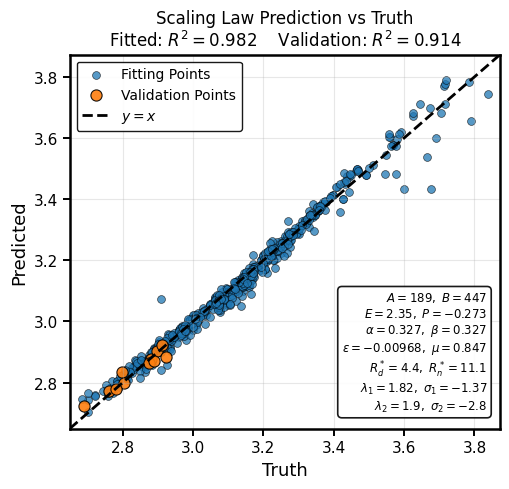

In [16]:
# ============================================================
# Plot Stage-4 scaling-law prediction vs truth
# Fitting points: STAGE12 + STAGE3 + STAGE4
# Validation points: NAMES_TO_VAL_LOSSES_N
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Make sure validation model sizes are included
# ------------------------------------------------------------
PARAMS_MAP.update({
    "1b92": 1.92e9,
    "3b84": 3.84e9,
    "7b68": 7.68e9,
})

a2, b2, e2, alpha2, epsion2, mu2, c2 = stage2_params
beta2 = alpha2
gamma1_2, gamma2_2 = stage3_params
c11_2, c12_2, c21_2, c22_2 = stage4_params
A2, B2, E2 = np.exp(a2), np.exp(b2), np.exp(e2)
    
# ------------------------------------------------------------
# Helper: parse one dictionary into arrays
# ------------------------------------------------------------
def collect_points_from_dict(names_to_val_losses):
    Ns = []
    Us = []
    Ds = []
    Ss = []
    ys = []
    point_names = []

    for name, loss_ in names_to_val_losses.items():
        if loss_ == 0 or name.endswith("dedup"):
            continue

        density, trimmed_name = get_density(name)
        p_raw, tok_start_idx = get_params(trimmed_name)
        U, tok_end_idx = get_unique_tokens(trimmed_name)
        D = get_tokens(trimmed_name[tok_start_idx:tok_end_idx])

        # N used in scaling_law is active / non-zero parameter count
        N_active = p_raw * density

        Ns.append(N_active)
        Us.append(U)
        Ds.append(D)
        Ss.append(density)
        ys.append(loss_)
        point_names.append(name)

    return {
        "N": np.array(Ns, dtype=float),
        "U": np.array(Us, dtype=float),
        "D": np.array(Ds, dtype=float),
        "S": np.array(Ss, dtype=float),
        "y": np.array(ys, dtype=float),
        "names": point_names,
    }


# ------------------------------------------------------------
# Build fitting dataset
# ------------------------------------------------------------
fit_dicts = [
    one_epoch_results,
    Dense_MultiEpoch_Results,
    Sparse_MultiEpoch_Results,
]

fit_data_list = [collect_points_from_dict(d) for d in fit_dicts]

fit_N = np.concatenate([d["N"] for d in fit_data_list])
fit_U = np.concatenate([d["U"] for d in fit_data_list])
fit_D = np.concatenate([d["D"] for d in fit_data_list])
fit_S = np.concatenate([d["S"] for d in fit_data_list])
fit_y = np.concatenate([d["y"] for d in fit_data_list])
fit_names = sum([d["names"] for d in fit_data_list], [])

# ------------------------------------------------------------
# Build validation dataset
# ------------------------------------------------------------
val_data = collect_points_from_dict(NAMES_TO_VAL_LOSSES_N)

val_N = val_data["N"]
val_U = val_data["U"]
val_D = val_data["D"]
val_S = val_data["S"]
val_y = val_data["y"]
val_names = val_data["names"]


# ------------------------------------------------------------
# Predict
# ------------------------------------------------------------
fit_pred = scaling_law(fit_N, fit_U, fit_D, fit_S)
val_pred = scaling_law(val_N, val_U, val_D, val_S)

fit_r2 = r2_score(fit_y, fit_pred)
val_r2 = r2_score(val_y, val_pred)

print(f"Fitting R^2:    {fit_r2:.4f}")
print(f"Validation R^2: {val_r2:.4f}")

print("\nValidation points:")
for name, y_true, y_pred in zip(val_names, val_y, val_pred):
    print(f"{name:20s} truth={y_true:.4f}, pred={y_pred:.4f}, err={y_pred-y_true:+.4f}")


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------
all_y = np.concatenate([fit_y, val_y])
all_pred = np.concatenate([fit_pred, val_pred])

vmin = min(all_y.min(), all_pred.min())
vmax = max(all_y.max(), all_pred.max())

pad = 0.03 * (vmax - vmin)
vmin -= pad
vmax += pad

fig, ax = plt.subplots(figsize=(5.2, 5.0))

# ------------------------------------------------------------
# Fitting points
# ------------------------------------------------------------
ax.scatter(
    fit_y,
    fit_pred,
    s=32,
    alpha=0.75,
    color="tab:blue",
    edgecolor="black",
    linewidth=0.45,
    label="Fitting Points",
)

# ------------------------------------------------------------
# Validation points
# ------------------------------------------------------------
ax.scatter(
    val_y,
    val_pred,
    s=65,
    alpha=0.9,
    color="tab:orange",
    edgecolor="black",
    linewidth=0.8,
    label="Validation Points",
)

# ------------------------------------------------------------
# y = x line
# ------------------------------------------------------------
ax.plot(
    [vmin, vmax],
    [vmin, vmax],
    linestyle="--",
    linewidth=2.0,
    color="black",
    label=r"$y=x$",
)

ax.set_xlim(vmin, vmax)
ax.set_ylim(vmin, vmax)

ax.set_xlabel("Truth", fontsize=13)
ax.set_ylabel("Predicted", fontsize=13)

ax.set_title(
    rf"Scaling Law Prediction vs Truth"
    "\n"
    rf"Fitted: $R^2={fit_r2:.3f}$    Validation: $R^2={val_r2:.3f}$",
    fontsize=12,
)

# ------------------------------------------------------------
# Bold plot border
# ------------------------------------------------------------
for spine in ax.spines.values():
    spine.set_linewidth(1.8)
    spine.set_color("black")

ax.tick_params(
    axis="both",
    which="both",
    width=1.4,
    length=5,
    labelsize=11,
)


param_text = (
    rf"$A={A2:.3g},\ B={B2:.3g}$" "\n"
    rf"$E={E2:.3g},\ P={c2:.3g}$" "\n"
    rf"$\alpha={alpha2:.3g},\ \beta={beta2:.3g}$" "\n"
    rf"$\epsilon={epsion2:.3g},\ \mu={mu2:.3g}$" "\n"
    rf"$R_d^*={gamma2_2:.3g},\ R_n^*={gamma1_2:.3g}$" "\n"
    rf"$\lambda_1={c12_2:.3g},\ \sigma_1={-c22_2:.3g}$" "\n"
    rf"$\lambda_2={c11_2:.3g},\ \sigma_2={-c21_2:.3g}$"
)

param_box = ax.text(
    0.97,
    0.04,
    param_text,
    transform=ax.transAxes,
    fontsize=8.5,
    va="bottom",
    ha="right",
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="black",
        linewidth=1.2,
        alpha=0.9,
    ),
)

ax.grid(alpha=0.3, linewidth=0.8)

legend = ax.legend(
    frameon=True,
    fontsize=10,
    loc="upper left",
)

legend.get_frame().set_edgecolor("black")
legend.get_frame().set_linewidth(1.0)
legend.get_frame().set_alpha(0.9)

plt.tight_layout()
plt.savefig("stage4_prediction_vs_truth.pdf", bbox_inches="tight")
plt.savefig("stage4_prediction_vs_truth.png", dpi=300, bbox_inches="tight")
plt.show()